## Introduction

In the previous notebook, we explored **Neural ODEs** for modeling continuous-time dynamics directly in the observable state space. We learned differential equations of the form:

$$\frac{dy}{dt} = f_\theta(y, t)$$

where $y$ represents the observable state (e.g., population counts, case numbers) and $f_\theta$ is a neural network.

**Data-space Neural ODEs** are powerful for trajectory prediction: by training on many trajectories, we learn a vector field that generates similar dynamics. Given a new initial condition, we can predict the future trajectory. This is useful when the goal is forecasting.

## When Data-Space ODEs Aren't Enough

Many problems, however, require inferring latent variables from observed trajectories rather than forecasting future states. Consider our task of predicting the spiral parameter $\alpha$ from a noisy spiral trajectory. The spiral itself is a noisy observation of an underlying generative process, and our goal is to infer the parameter $\alpha$ that governs it. This is fundamentally a regression problem on time series data, requiring a model that can process sequential observations, accumulate evidence about the generative parameter, and decode that representation to produce a prediction.

## The Latent ODE Framework

**Latent Neural ODEs** address this by learning dynamics in a learned latent representation space rather than in the observation space.

The model has three components:

1. **Encoder (recurrent update)**: Incorporates observations $x_t$ into a latent state $h_t$
2. **Latent ODE**: Evolves the latent state continuously between observations:
   $$\frac{dh}{dt} = f_\theta(h, t)$$
3. **Decoder**: Maps the final latent state $h_T$ to a prediction $\hat{y}$

The key insight: the latent state $h$ accumulates evidence about the underlying generative parameter as it observes more of the trajectory.

## GRU-ODE: A Hybrid Approach

We'll implement a **GRU-ODE** architecture that combines:
- **GRU (Gated Recurrent Unit)**: Updates the latent state at each observation
- **Neural ODE**: Evolves the latent state between observations

**Architecture flow:**
1. Initialize hidden state $h_0$
2. For each observation $x_t$ at time $t$:
   - **ODE Evolution**: $h_{t^-} = \text{ODESolve}(h_{t-1}, t_{t-1} \to t)$
   - **GRU Update**: $h_t = \text{GRU}(x_t, h_{t^-})$
3. Use final hidden state $h_T$ to predict output via a linear decoder

This design allows the model to learn continuous dynamics in latent space via the ODE, incorporate new observations discretely via the GRU, and handle arbitrary time gaps naturally, which is helpful for irregular sampling.

## The Task: Spiral Regression

We'll train the GRU-ODE on a synthetic dataset of 2D spirals with varying spiral parameters. Each spiral is parameterized by $\alpha$, and our goal is to predict $\alpha$ from the observed trajectory.

**Key experiment**: We'll test the model's robustness to irregular sampling by training and evaluating on datasets with different observation densities:
- **100%**: All timesteps observed
- **75%**: 25% of timesteps randomly dropped
- **50%**: 50% of timesteps randomly dropped
- **25%**: 75% of timesteps randomly dropped

This demonstrates how Latent ODEs can handle irregularly sampled time series and missing observations.

## Architecture Details

### ODE Function

The ODE function defines how the hidden state evolves continuously between observations:

$$\frac{dh}{dt} = f_\theta(h, t)$$

We parameterize $f_\theta$ as a multi-layer perceptron (MLP) that takes the concatenation of the hidden state $h$ and time $t$ as input. The output is scaled by a learnable parameter to allow the model to learn appropriate derivative magnitudes.

### GRU-ODE Model

The complete GRU-ODE architecture processes a sequence as follows:

1. **Initialize** the hidden state $h_0$ (a learnable parameter)
2. **Incorporate the first observation**:
   - $h_0 \leftarrow \text{GRU}(x_0, h_0)$
3. **For each timestep** $i = 0, 1, \ldots, T-1$:
   - Solve the ODE from $t_i$ to $t_{i+1}$:
     $$h_{i+1}^- = h_i + \int_{t_i}^{t_{i+1}} f_\theta(h(\tau), \tau)\, d\tau$$
   - Apply GRU update with the next observation (if available):
     $$h_{i+1} = \text{GRU}(x_{i+1}, h_{i+1}^-)$$
4. **Decode** the final hidden state:
   $$\hat{y} = W h_T + b$$

The combination of continuous ODE evolution and discrete GRU updates allows the model to interpolate between observations while incorporating new information when it arrives, making it well suited to irregularly sampled time series.

In [2]:
import equinox as eqx
import jax
import jax.nn as jnn
import jax.numpy as jnp
import diffrax
import optax
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

In [3]:
# ============================================================
#  ODE FUNCTION
# ============================================================
class ODEFunc(eqx.Module):
    mlp: eqx.nn.MLP
    out_scale: jnp.ndarray

    def __init__(self, hidden_dim: int, width: int = 64, depth: int = 2, *, key):
        self.mlp = eqx.nn.MLP(
            in_size=hidden_dim + 1,
            out_size=hidden_dim,
            width_size=width,
            depth=depth,
            activation=jnn.tanh,
            final_activation=lambda x: x,
            key=key,
        )
        self.out_scale = jnp.array(1.0, dtype=jnp.float32)

    def __call__(self, t, h, args):
        inp = jnp.concatenate([h, jnp.atleast_1d(t)])
        return self.out_scale * self.mlp(inp)


# ============================================================
#  GRU-ODE REGRESSOR (Heun)
# ============================================================
class GRUODERegressor(eqx.Module):
    ode_func: ODEFunc
    gru_cell: eqx.nn.GRUCell
    decoder: eqx.nn.Linear
    h0: jnp.ndarray

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int,
                 width: int = 64, depth: int = 2, *, key):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.ode_func = ODEFunc(hidden_dim, width=width, depth=depth, key=k1)
        self.gru_cell = eqx.nn.GRUCell(input_size=input_dim, hidden_size=hidden_dim, key=k2)
        self.decoder = eqx.nn.Linear(hidden_dim, output_dim, key=k3)
        self.h0 = jax.random.normal(k4, (hidden_dim,), dtype=jnp.float32) * 0.1

    def __call__(self, ts, xs):
        solver = diffrax.Heun()
        term = diffrax.ODETerm(self.ode_func)
        dt = 0.005
        stepsize_controller = diffrax.ConstantStepSize()

        h_init = self.gru_cell(xs[0], self.h0)

        def step_fn(h, i):
            t0 = ts[i]
            t1 = ts[i + 1]
            x_next = xs[i + 1]

            sol = diffrax.diffeqsolve(
                term,
                solver=solver,
                t0=t0,
                t1=t1,
                dt0=dt,
                y0=h,
                saveat=diffrax.SaveAt(t1=True),
                stepsize_controller=stepsize_controller,
                adjoint=diffrax.RecursiveCheckpointAdjoint(),
            )

            h_ode = sol.ys.reshape(h.shape)
            h_new = self.gru_cell(x_next, h_ode)
            return h_new, None

        h_final, _ = jax.lax.scan(step_fn, h_init, jnp.arange(len(ts) - 1))
        return self.decoder(h_final)

## Training Setup

We train the GRU-ODE using mean squared error (MSE) loss between predicted and true spiral parameters $\alpha$. The training procedure processes batches of spiral trajectories, where each trajectory consists of $(x, y)$ coordinates observed at times $t_0, t_1, \ldots, t_T$.

For efficient training, we:
1. Compute the loss by vmapping the model over the batch
2. Use gradient descent with the Adam optimizer
3. Apply JIT compilation to accelerate both forward and backward passes

The model learns to accumulate evidence about $\alpha$ as it processes each observation, with the ODE evolution allowing it to naturally handle varying time gaps between observations.

In [4]:
@eqx.filter_value_and_grad
def grad_loss(model, ts_batch, xs_batch, y_batch):
    batched_model = jax.vmap(model, in_axes=(0, 0))
    y_pred = batched_model(ts_batch, xs_batch)
    return jnp.mean((y_pred - y_batch) ** 2)

@eqx.filter_jit
def train_step(model, opt_state, ts_batch, xs_batch, y_batch, optimizer):
    loss, grads = grad_loss(model, ts_batch, xs_batch, y_batch)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state

## Experiment: Robustness to Irregular Sampling
To evaluate the GRU-ODE's ability to handle irregular time series, we use a synthetic spiral dataset with varying observation densities. Each spiral is generated by the parametric equations in polar coordinates:
$$r(\theta) = \alpha \theta$$
which in Cartesian coordinates becomes:
$$x(t) = \alpha t \cos(t), \quad y(t) = \alpha t \sin(t)$$
where $t$ serves as both the time parameter and the angular coordinate $\theta$, and $\alpha$ is the spiral constant we aim to predict. Note that negative values of $\alpha$ produce spirals rotated 180° relative to positive values of the same magnitude. The spirals are observed at discrete timesteps with additive Gaussian noise.

We test on four datasets with different sampling densities:
- **spirals_100.npz**: 100% of timesteps observed (fully sampled)
- **spirals_75.npz**: 75% of timesteps observed (25% randomly dropped)
- **spirals_50.npz**: 50% of timesteps observed (50% randomly dropped)
- **spirals_25.npz**: 25% of timesteps observed (75% randomly dropped)

This experimental design allows us to measure how prediction accuracy degrades as observations become sparser.

In [5]:
def load_spiral_dataset(name: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Load one of the spiral datasets (e.g., 'spirals_100.npz', 'spirals_75.npz', etc.)
    from the 'data/' subfolder.
    
    Parameters
    ----------
    name : str
        Dataset identifier (e.g., '100', '75', '50', '25')
    
    Returns
    -------
    data_train : np.ndarray
        Training set, shape (1000, n, 3)  [t, x, y]
    alpha_train : np.ndarray
        Training α values, shape (1000, 1)
    data_validation : np.ndarray
        Validation set, shape (1000, n, 3)
    alpha_validation : np.ndarray
        Validation α values, shape (1000, 1)
    data_test : np.ndarray
        Test set, shape (1000, n, 3)
    """
    path = f"data/spirals_{name}.npz"
    data = np.load(path)
    
    data_train = data["data_train"]
    alpha_train = data["alpha_train"]
    data_validation = data["data_validation"]
    alpha_validation = data["alpha_validation"]
    data_test = data["data_test"]
    
    print(f"✅ Loaded spirals_{name}")
    print(f"   Train data: {data_train.shape}, α_train: {alpha_train.shape}")
    print(f"   Validation data: {data_validation.shape}, α_val: {alpha_validation.shape}")
    print(f"   Test data: {data_test.shape}")
    
    return data_train, alpha_train, data_validation, alpha_validation, data_test

# Load all datasets (unchanged)
datasets = {}
for density in ['100', '75', '50', '25']:
    data_train, alpha_train, data_val, alpha_val, data_test = load_spiral_dataset(density)
    datasets[density] = {
        'data_train': data_train,
        'alpha_train': alpha_train,
        'data_val': data_val,
        'alpha_val': alpha_val,
        'data_test': data_test
    }
    print()

✅ Loaded spirals_100
   Train data: (1000, 100, 3), α_train: (1000, 1)
   Validation data: (1000, 100, 3), α_val: (1000, 1)
   Test data: (1000, 100, 3)

✅ Loaded spirals_75
   Train data: (1000, 75, 3), α_train: (1000, 1)
   Validation data: (1000, 75, 3), α_val: (1000, 1)
   Test data: (1000, 75, 3)

✅ Loaded spirals_50
   Train data: (1000, 50, 3), α_train: (1000, 1)
   Validation data: (1000, 50, 3), α_val: (1000, 1)
   Test data: (1000, 50, 3)

✅ Loaded spirals_25
   Train data: (1000, 25, 3), α_train: (1000, 1)
   Validation data: (1000, 25, 3), α_val: (1000, 1)
   Test data: (1000, 25, 3)



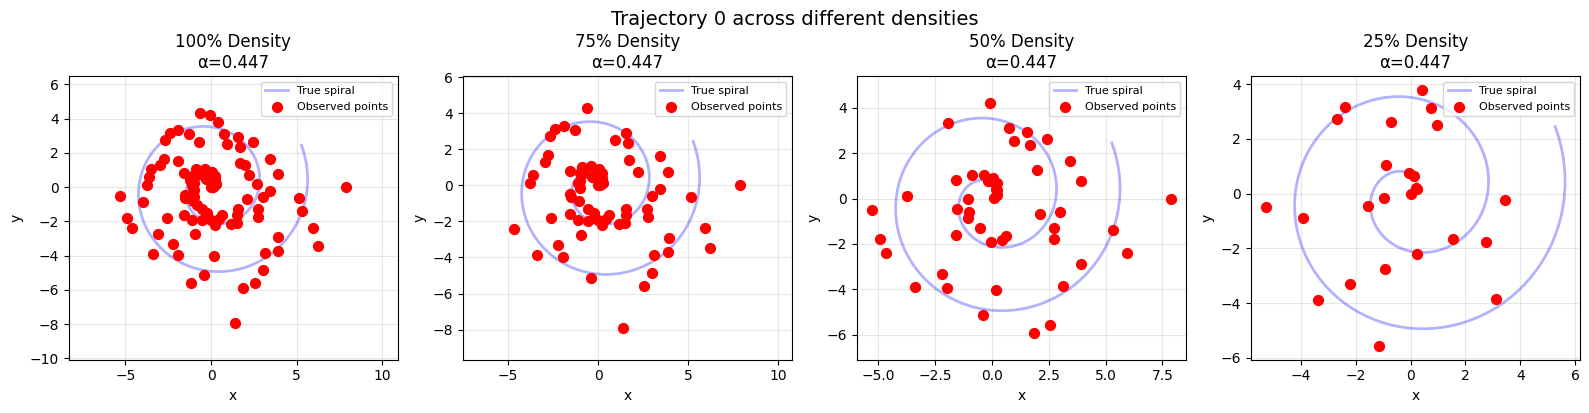

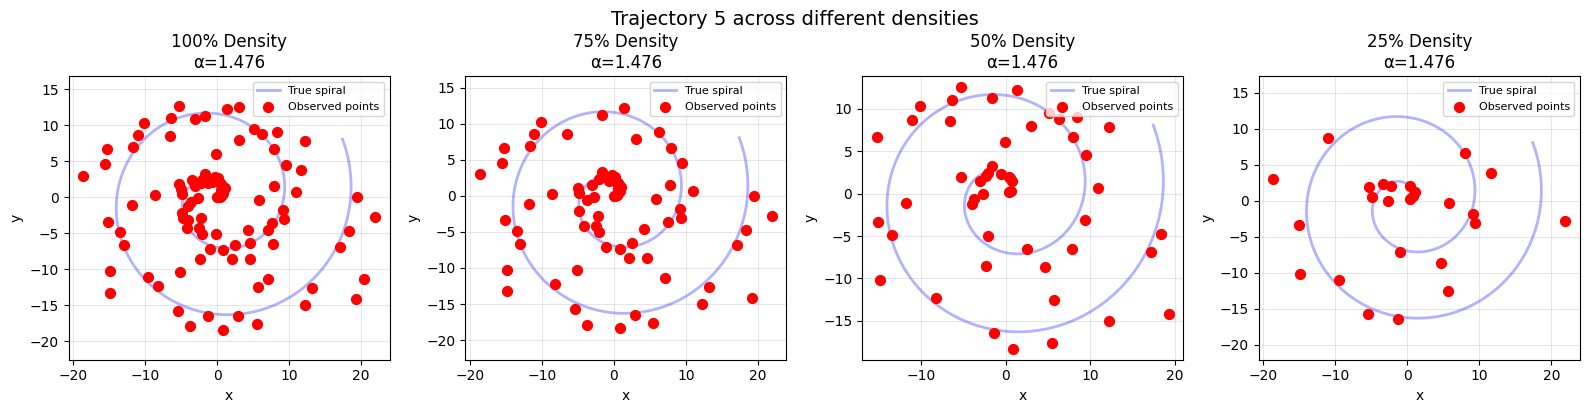

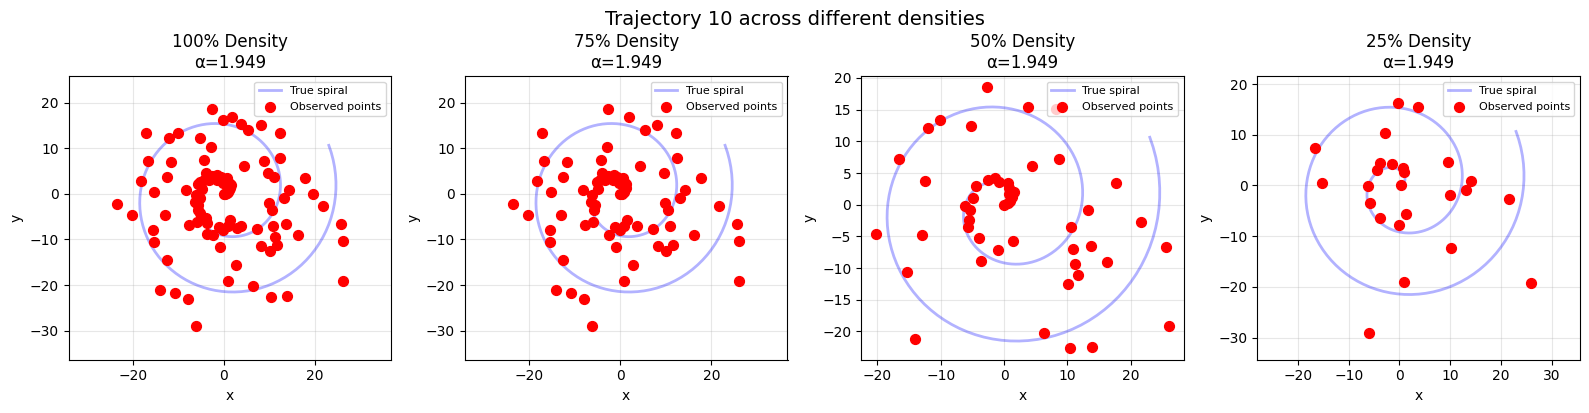

In [6]:
def generate_true_spiral(alpha: float, t_max: float = 1.0, n_points: int = 100):
    ts = np.linspace(0, t_max, n_points)
    theta = ts  # Use time as the angle parameter
    r = alpha * theta  # r = α·θ
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.stack([x, y], axis=-1)

def visualize_trajectories_with_true_spirals(datasets, trajectory_idx=0):
    densities = ['100', '75', '50', '25']
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    for idx, density in enumerate(densities):
        ax = axes[idx]
        
        # Get the trajectory and corresponding alpha
        trajectory = datasets[density]['data_train'][trajectory_idx]  # Shape: (n, 3)
        alpha = datasets[density]['alpha_train'][trajectory_idx, 0]
        
        # Extract observed points (non-NaN)
        # trajectory columns are [t, x, y]
        mask = ~np.isnan(trajectory[:, 1])  # Check x-values for NaN
        observed_x = trajectory[mask, 1]
        observed_y = trajectory[mask, 2]
        
        # Generate true spiral
        true_spiral = generate_true_spiral(alpha, t_max=13.0, n_points=200)
        
        # Plot true spiral
        ax.plot(true_spiral[:, 0], true_spiral[:, 1], 
                'b-', alpha=0.3, linewidth=2, label='True spiral')
        
        # Plot observed points
        ax.scatter(observed_x, observed_y, 
                   c='red', s=50, zorder=5, label='Observed points')
        
        # Formatting
        ax.set_title(f'{density}% Density\nα={alpha:.3f}', fontsize=12)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.grid(True, alpha=0.3)
        ax.axis('equal')
        ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.suptitle(f'Trajectory {trajectory_idx} across different densities', 
                 fontsize=14, y=1.02)
    plt.show()

# Visualize the first trajectory
visualize_trajectories_with_true_spirals(datasets, trajectory_idx=0)

# Optionally visualize a few more examples
visualize_trajectories_with_true_spirals(datasets, trajectory_idx=5)
visualize_trajectories_with_true_spirals(datasets, trajectory_idx=10)

## Data Normalization

To improve training stability and convergence, we normalize the input data and target values before feeding them to the model. The normalization is handled by a wrapper class that preprocesses inputs and postprocesses outputs, keeping all external data in original units.

### Normalization Strategy

**Time normalization (per sequence):**
$$t_{\text{norm}} = \frac{t - t_{\min}}{t_{\max} - t_{\min}}$$
Each trajectory's timestamps are independently scaled to [0, 1]. This handles the irregular sampling naturally - trajectories with different observation times are each normalized to their own [0, 1] range.

**Spatial standardization (global):**
$$x_{\text{norm}} = \frac{x - \mu_x}{\sigma_x}, \quad y_{\text{norm}} = \frac{y - \mu_y}{\sigma_y}$$
The (x, y) coordinates are standardized using the mean and standard deviation computed from all observations in the training set. This centers the spirals and scales them to unit variance.

**Target standardization:**
$$\alpha_{\text{norm}} = \frac{\alpha - \mu_\alpha}{\sigma_\alpha}$$
The spiral parameter $\alpha$ is standardized to have zero mean and unit variance on the training set.

### Implementation

Rather than modifying the dataset directly, we wrap the GRU-ODE model in a `NormalizedGRUODERegressor` class that:
1. Computes normalization statistics from the training data during initialization (these become non-trainable model parameters)
2. Automatically normalizes inputs in the forward pass
3. Automatically denormalizes outputs back to original units

This design keeps the training data in its original form while ensuring the core model sees well-scaled inputs. All loss computations and predictions are in original units, making results directly interpretable.

In [7]:
# ============================================================
#  NORMALIZED GRU-ODE WRAPPER
# ============================================================
class NormalizedGRUODERegressor(eqx.Module):
    """Wrapper that normalizes inputs and denormalizes alpha predictions."""
    core_model: GRUODERegressor
    mean_xy: jnp.ndarray
    std_xy: jnp.ndarray
    mean_alpha: jnp.ndarray
    std_alpha: jnp.ndarray
    
    def __init__(self, core_model, data_train, alpha_train):
        self.core_model = core_model
        
        # Compute normalization statistics from training data
        xy_train = data_train[..., 1:]  # Extract x, y
        self.mean_xy = jnp.array(np.mean(xy_train, axis=(0, 1)), dtype=jnp.float32)
        self.std_xy = jnp.array(np.std(xy_train, axis=(0, 1)) + 1e-8, dtype=jnp.float32)
        
        self.mean_alpha = jnp.array(np.mean(alpha_train), dtype=jnp.float32)
        self.std_alpha = jnp.array(np.std(alpha_train) + 1e-8, dtype=jnp.float32)
        
        print("✅ Normalization wrapper initialized")
        print(f"   x/y mean={self.mean_xy}, std={self.std_xy}")
        print(f"   alpha mean={self.mean_alpha:.4f}, std={self.std_alpha:.4f}")
    
    def normalize_time(self, t):
        """Normalize time to [0, 1] per sequence."""
        if t.ndim == 1:
            t_min = jnp.min(t)
            t_max = jnp.max(t)
        elif t.ndim == 2:
            t_min = jnp.min(t, axis=1, keepdims=True)
            t_max = jnp.max(t, axis=1, keepdims=True)
        else:
            raise ValueError(f"t must have shape (T,) or (B,T); got {t.shape}")
        return (t - t_min) / (t_max - t_min + 1e-8)
    
    def normalize_xy(self, xy):
        """Standardize x, y coordinates."""
        return (xy - self.mean_xy) / self.std_xy
    
    def normalize_alpha(self, alpha):
        """Standardize alpha."""
        return (alpha - self.mean_alpha) / self.std_alpha
    
    def denormalize_alpha(self, alpha_norm):
        """Convert normalized alpha back to original units."""
        return alpha_norm * self.std_alpha + self.mean_alpha
    
    def __call__(self, ts, xs):
        """Forward pass with automatic normalization/denormalization."""
        ts_norm = self.normalize_time(ts)
        xs_norm = self.normalize_xy(xs)
        alpha_norm = self.core_model(ts_norm, xs_norm)
        return self.denormalize_alpha(alpha_norm)

## Training and Evaluating GRU-ODE Models Across Observation Densities

We train and evaluate a separate GRU-ODE model for each spiral observation density (100%, 75%, 50%, and 25%). For each density, the model is initialized with the same architecture and hyperparameters and wrapped with a normalization layer computed from the corresponding training data.

Each model is trained only on its own density and evaluated on the matching validation set. This allows us to isolate the effect of observation sparsity on performance without parameter sharing across datasets.

Evaluation includes both overall prediction accuracy for the spiral parameter $\alpha$ and a qualitative visualization of a single validation trajectory, comparing the true spiral with the spiral generated from the model’s prediction.

In [8]:
def make_model_for_density(
    datasets: dict,
    density: str,
    *,
    seed: int = 42,
    hidden_dim: int = 64,
    width: int = 64,
    depth: int = 2,
):
    data_train = datasets[density]["data_train"]
    alpha_train = datasets[density]["alpha_train"]
    data_val = datasets[density]["data_val"]
    alpha_val = datasets[density]["alpha_val"]

    key = jax.random.PRNGKey(seed)

    core_model = GRUODERegressor(
        input_dim=2,
        hidden_dim=hidden_dim,
        output_dim=1,
        width=width,
        depth=depth,
        key=key,
    )

    model = NormalizedGRUODERegressor(core_model, data_train, alpha_train)
    print(f"✅ Model initialized for spirals_{density} (seed={seed})")

    return model, data_train, alpha_train, data_val, alpha_val, key

In [9]:
def train_model(
    model,
    data_train,
    alpha_train,
    data_val,
    alpha_val,
    *,
    key,
    learning_rate: float = 5e-3,
    num_epochs: int = 10,
    batch_size: int = 64,
    desc: str = "Training",
    plot: bool = True,
):
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

    data_train_jax = jnp.array(data_train, dtype=jnp.float32)
    alpha_train_jax = jnp.array(alpha_train, dtype=jnp.float32)
    data_val_jax = jnp.array(data_val, dtype=jnp.float32)
    alpha_val_jax = jnp.array(alpha_val, dtype=jnp.float32)

    n_train = data_train_jax.shape[0]
    n_batches = max(1, int(np.ceil(n_train / batch_size)))  # ← minimal fix

    loss_history = []
    val_loss_history = []

    from tqdm import trange
    progress = trange(num_epochs, desc=desc)
    for epoch in progress:
        key, subkey = jax.random.split(key)
        perm = jax.random.permutation(subkey, n_train)
        data_shuffled = data_train_jax[perm]
        alpha_shuffled = alpha_train_jax[perm]

        epoch_losses = []
        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, n_train)

            data_batch = data_shuffled[start_idx:end_idx]
            alpha_batch = alpha_shuffled[start_idx:end_idx]

            ts_batch = data_batch[..., 0]
            xs_batch = data_batch[..., 1:]

            loss, model, opt_state = train_step(
                model, opt_state, ts_batch, xs_batch, alpha_batch, optimizer
            )
            epoch_losses.append(loss)

        train_loss = float(jnp.mean(jnp.stack(epoch_losses)))
        loss_history.append(train_loss)

        ts_val = data_val_jax[..., 0]
        xs_val = data_val_jax[..., 1:]
        val_loss, _ = grad_loss(model, ts_val, xs_val, alpha_val_jax)
        val_loss = float(val_loss)
        val_loss_history.append(val_loss)

        progress.set_postfix({"train": f"{train_loss:.4f}", "val": f"{val_loss:.4f}"})

    if plot:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(10, 5))
        plt.plot(loss_history, label="Train", linewidth=1.5)
        plt.plot(val_loss_history, label="Val", linewidth=1.5)
        plt.yscale("log")
        plt.title(desc)
        plt.xlabel("Epoch")
        plt.ylabel("MSE")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return model, loss_history, val_loss_history, key

✅ Normalization wrapper initialized
   x/y mean=[ 0.00221817 -0.04279724], std=[13.228789 13.00915 ]
   alpha mean=0.0571, std=2.4921
✅ Model initialized for spirals_100 (seed=42)


spirals_100: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [05:52<00:00,  8.82s/it, train=0.0220, val=0.1001]


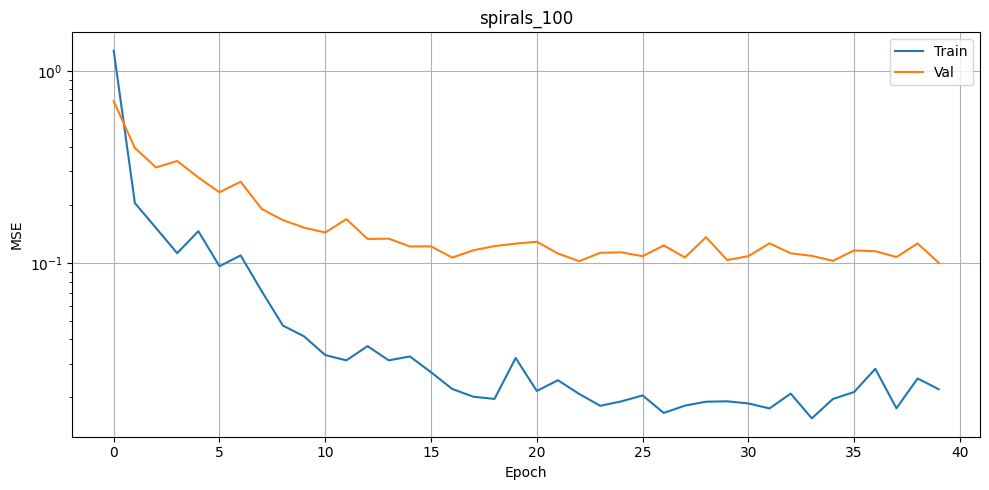

✅ Normalization wrapper initialized
   x/y mean=[ 0.0346475  -0.04468465], std=[13.177493  13.0025625]
   alpha mean=0.0571, std=2.4921
✅ Model initialized for spirals_75 (seed=43)


spirals_75: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [1:14:34<00:00, 111.85s/it, train=0.0155, val=0.1148]


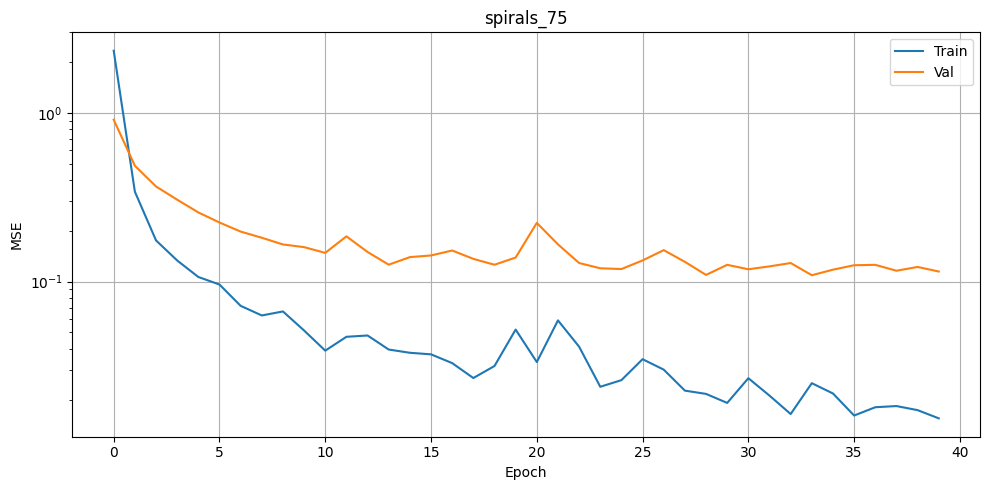

✅ Normalization wrapper initialized
   x/y mean=[-0.04370974 -0.0321009 ], std=[13.374674  13.1175375]
   alpha mean=0.0571, std=2.4921
✅ Model initialized for spirals_50 (seed=44)


spirals_50: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [3:17:49<00:00, 296.74s/it, train=0.0199, val=0.1902]


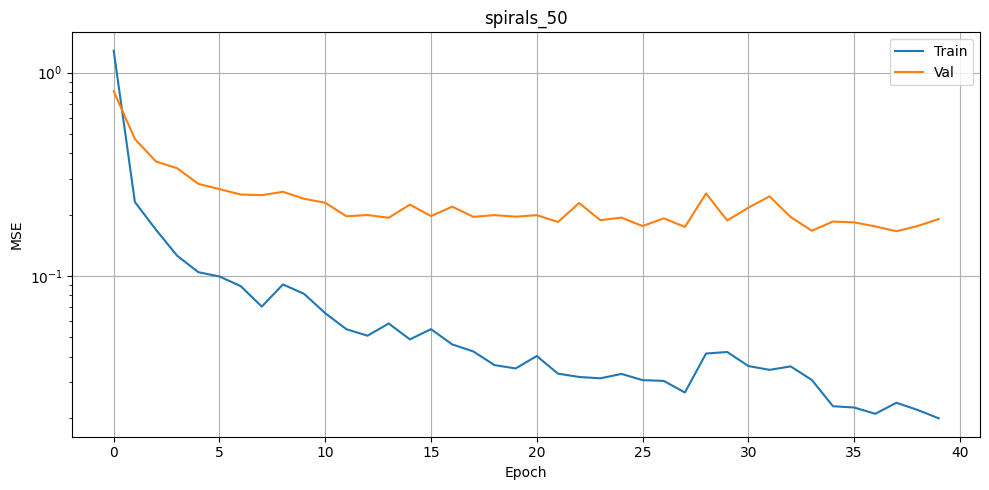

✅ Normalization wrapper initialized
   x/y mean=[0.07632695 0.01462931], std=[13.418946 13.123611]
   alpha mean=0.0571, std=2.4921
✅ Model initialized for spirals_25 (seed=45)


spirals_25: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [3:18:21<00:00, 297.54s/it, train=0.0415, val=0.3166]


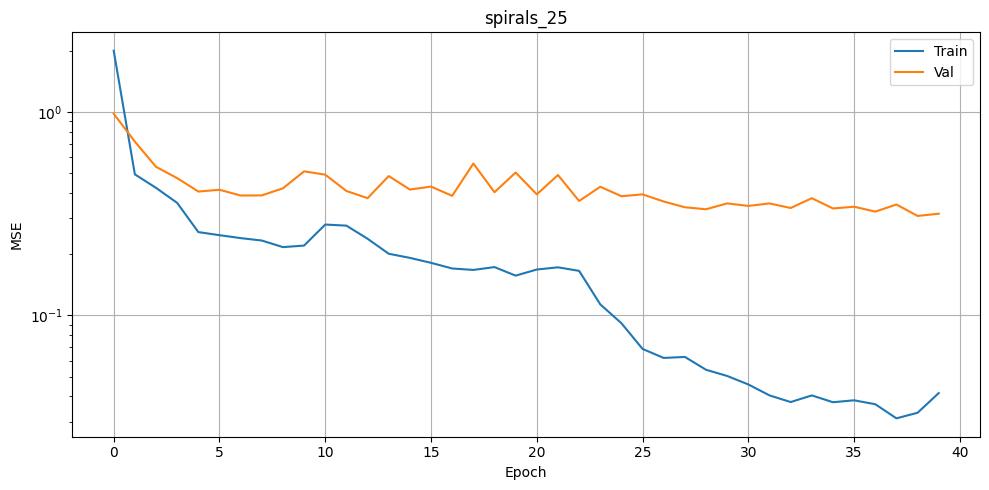

In [10]:
# Train one model per density and keep everything (models + loss curves)
densities = ["100", "75", "50", "25"]

trained = {}  # density -> {"model": ..., "train": [...], "val": [...], "key": ...}

base_seed = 42

for i, density in enumerate(densities):
    # 1) build model + get splits for this density
    model, data_train, alpha_train, data_val, alpha_val, key = make_model_for_density(
        datasets,
        density,
        seed=base_seed + i,   # different init per density
        hidden_dim=64,
        width=64,
        depth=2,
    )

    # 2) train + plot losses for this density
    model, train_hist, val_hist, key = train_model(
        model,
        data_train, alpha_train,
        data_val, alpha_val,
        key=key,
        learning_rate=5e-3,
        num_epochs=40,
        batch_size=64,
        desc=f"spirals_{density}",
        plot=True,
    )

    # 3) store results
    trained[density] = {
        "model": model,
        "train_loss": train_hist,
        "val_loss": val_hist,
        "key": key,
    }


📊 Validation Set Performance (spirals_100)
   MSE: 0.100117
   MAE: 0.095856
   Std of errors: 0.314198


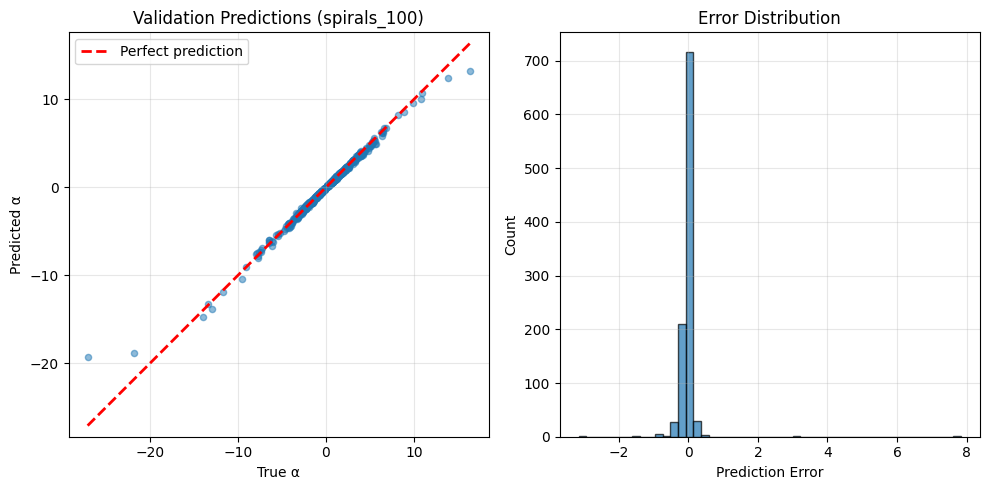


📊 Validation Set Performance (spirals_75)
   MSE: 0.114802
   MAE: 0.105047
   Std of errors: 0.335568


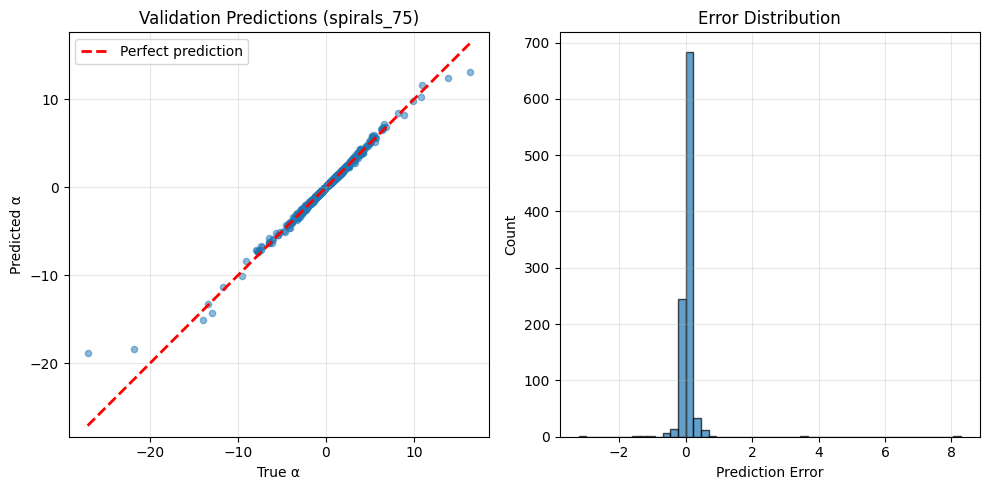


📊 Validation Set Performance (spirals_50)
   MSE: 0.190209
   MAE: 0.133620
   Std of errors: 0.435194


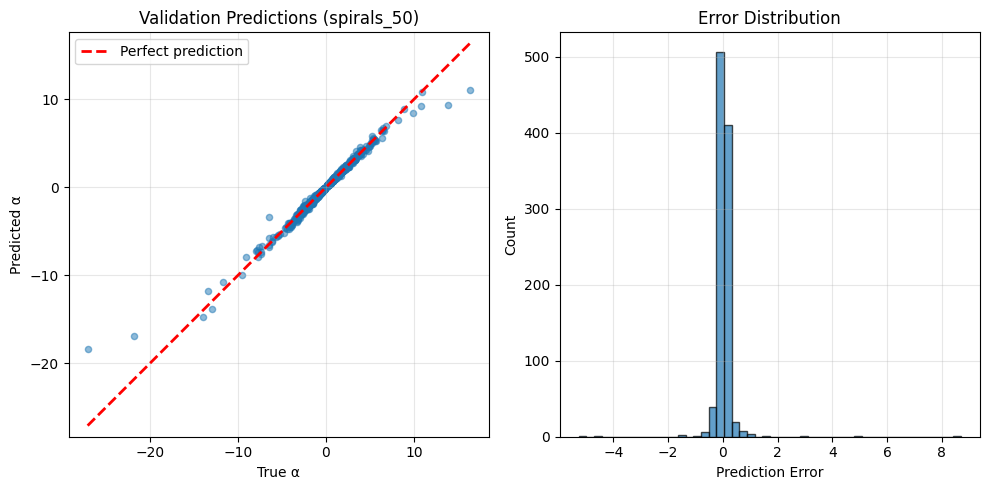


📊 Validation Set Performance (spirals_25)
   MSE: 0.316607
   MAE: 0.194341
   Std of errors: 0.560327


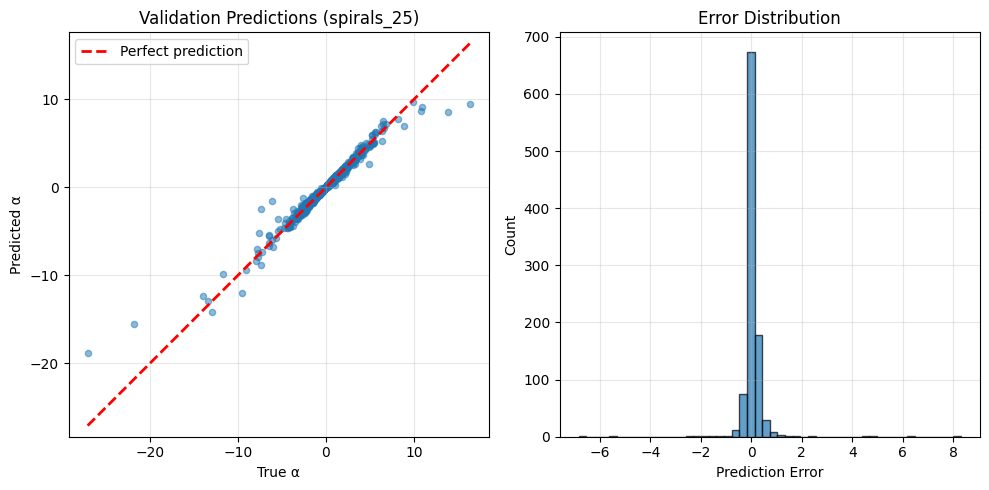

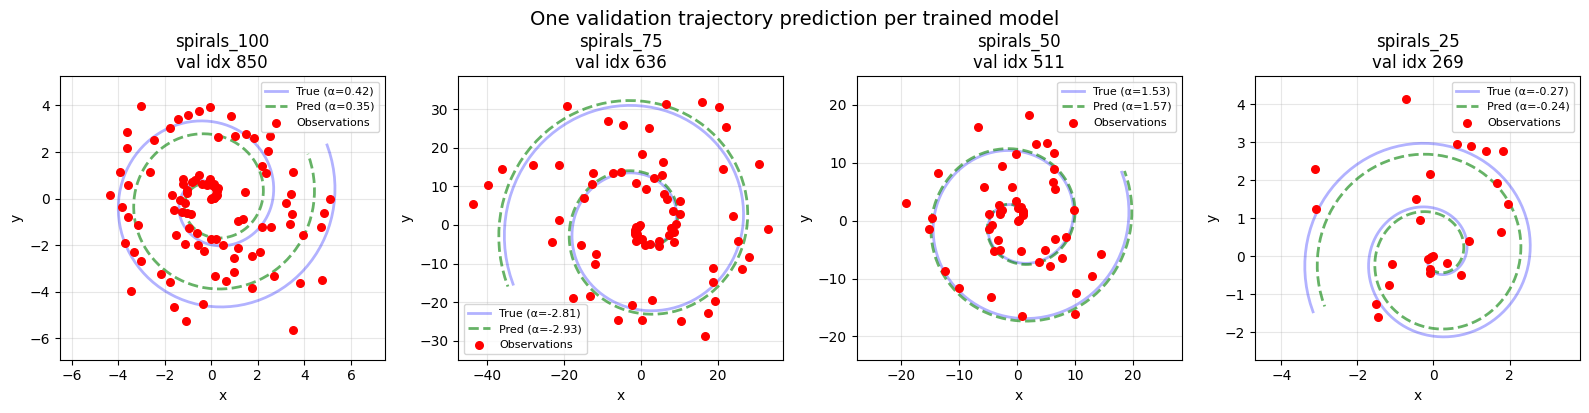

In [11]:
# Evaluate all trained models (one chosen validation trajectory per density)

densities = ["100", "75", "50", "25"]

# pick ONE validation trajectory index per density (reproducible)
rng = np.random.default_rng(0)
sample_idx_by_density = {}

# --- 1) per-density metrics plots (scatter + error hist) + summary stats ---
for density in densities:
    model = trained[density]["model"]
    data_val = datasets[density]["data_val"]
    alpha_val = datasets[density]["alpha_val"]

    data_val_jax = jnp.array(data_val, dtype=jnp.float32)
    alpha_val_jax = jnp.array(alpha_val, dtype=jnp.float32)

    ts_val = data_val_jax[..., 0]
    xs_val = data_val_jax[..., 1:]

    batched_model = jax.vmap(model, in_axes=(0, 0))
    alpha_pred = batched_model(ts_val, xs_val)

    alpha_pred_np = np.array(alpha_pred).reshape(-1)
    alpha_val_np = np.array(alpha_val).reshape(-1)

    errors = alpha_pred_np - alpha_val_np
    mse = float(np.mean(errors**2))
    mae = float(np.mean(np.abs(errors)))
    err_std = float(np.std(errors))

    print(f"\n📊 Validation Set Performance (spirals_{density})")
    print(f"   MSE: {mse:.6f}")
    print(f"   MAE: {mae:.6f}")
    print(f"   Std of errors: {err_std:.6f}")

    # one trajectory index per density (store it so we can reuse below)
    if density not in sample_idx_by_density:
        sample_idx_by_density[density] = int(rng.integers(0, len(data_val)))

    # plots for this density
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(alpha_val_np, alpha_pred_np, alpha=0.5, s=20)
    lo = min(alpha_val_np.min(), alpha_pred_np.min())
    hi = max(alpha_val_np.max(), alpha_pred_np.max())
    plt.plot([lo, hi], [lo, hi], "r--", linewidth=2, label="Perfect prediction")
    plt.xlabel("True α")
    plt.ylabel("Predicted α")
    plt.title(f"Validation Predictions (spirals_{density})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis("equal")

    plt.subplot(1, 2, 2)
    plt.hist(errors, bins=50, edgecolor="black", alpha=0.7)
    plt.xlabel("Prediction Error")
    plt.ylabel("Count")
    plt.title("Error Distribution")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# --- 2) one trajectory spiral visualization per model (4 panels) ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, density in zip(axes, densities):
    model = trained[density]["model"]
    data_val = datasets[density]["data_val"]
    alpha_val = datasets[density]["alpha_val"]

    sample_idx = sample_idx_by_density[density]

    # single sample
    traj = data_val[sample_idx]  # (T, 3) [t, x, y]
    ts = jnp.array(traj[:, 0], dtype=jnp.float32)
    xs = jnp.array(traj[:, 1:], dtype=jnp.float32)

    alpha_true = float(alpha_val[sample_idx].reshape(-1)[0])
    alpha_pred = float(np.array(model(ts, xs)).reshape(-1)[0])

    # observed points (mask NaNs just in case)
    mask = ~np.isnan(traj[:, 1])
    observed_x = traj[mask, 1]
    observed_y = traj[mask, 2]

    true_spiral = generate_true_spiral(alpha_true, t_max=13.0, n_points=200)
    pred_spiral = generate_true_spiral(alpha_pred, t_max=13.0, n_points=200)

    ax.plot(true_spiral[:, 0], true_spiral[:, 1],
            "b-", alpha=0.3, linewidth=2, label=f"True (α={alpha_true:.2f})")
    ax.plot(pred_spiral[:, 0], pred_spiral[:, 1],
            "g--", alpha=0.6, linewidth=2, label=f"Pred (α={alpha_pred:.2f})")
    ax.scatter(observed_x, observed_y,
               c="red", s=30, zorder=5, label="Observations")

    ax.set_title(f"spirals_{density}\nval idx {sample_idx}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
    ax.axis("equal")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle("One validation trajectory prediction per trained model", fontsize=14, y=1.02)
plt.show()

# Discussion

## Robustness to Irregular Sampling

Across all observation densities, the GRU-ODE model performs well at inferring the spiral parameter $\alpha$, even when a large fraction of observations is missing. Performance degrades as sampling becomes sparser, but remains reasonable even at 25% observation density. This demonstrates the model’s ability to integrate information across irregular and inconsistent timesteps using continuous-time latent dynamics.

## Error Patterns and Data Coverage

Prediction errors are largest for trajectories with extreme values of $\alpha$ (roughly $\alpha < -20$ or $\alpha > 20$). These regimes are underrepresented in the training data, suggesting that the reduced performance is driven by limited data coverage rather than architectural limitations. Improving accuracy in these regions would likely require generating or collecting additional training examples with large-magnitude $\alpha$ values.

## Key Takeaway

The combination of continuous latent ODE evolution and discrete GRU updates allows the model to infer global properties of a trajectory even from sparse observations. Qualitative visualizations confirm that predicted spirals closely match the true generative spirals despite substantial observation dropout.

## Conclusion

This experiment shows that GRU-ODEs are well suited for regression tasks on irregularly sampled time series. The model remains effective under significant missingness and produces stable, interpretable predictions without explicit imputation. These results highlight latent ODE-based architectures as a strong choice for learning from real-world sequential data, where uneven sampling is common.